# MNIST Autoencoder Project

This notebook demonstrates a LeakyReLU Dense Autoencoder trained on the MNIST dataset. It includes data preparation, model training, evaluation under noisy conditions, and performance visualization.

## 1. Install and Import Necessary Libraries

First, we install and import the packages needed for image processing, model building, and visualization.

In [1]:
pip install -q torch torchvision scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Standard library
import os
import random

# Data & visualization
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Torchvision
import torchvision.datasets as datasets
import torchvision.transforms as transforms

## 2. Configuration & Experiment Setup

We set seeds for reproducibility and define hyperparameters such as batch size, learning rate, and dataset size.

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Configure all 4 experimental runs
runs_config = [
    {"run_id": 1, "subset_size": 2500, "epochs": 50, "lr": 0.01},
    {"run_id": 2, "subset_size": 2500, "epochs": 100, "lr": 0.01},
    {"run_id": 3, "subset_size": 5000, "epochs": 50, "lr": 0.01},
    {"run_id": 4, "subset_size": 5000, "epochs": 100, "lr": 0.01}
]

BATCH_SIZE = 64

print("=" * 55)
print("TRAINING EXPERIMENT SETUP")
for run in runs_config:
    print(f"• Run {run['run_id']}: Dataset Size = {run['subset_size']}, Epochs = {run['epochs']}, LR = {run['lr']}")
print("=" * 55)
print(DEVICE)

TRAINING EXPERIMENT SETUP
• Run 1: Dataset Size = 2500, Epochs = 50, LR = 0.01
• Run 2: Dataset Size = 2500, Epochs = 100, LR = 0.01
• Run 3: Dataset Size = 5000, Epochs = 50, LR = 0.01
• Run 4: Dataset Size = 5000, Epochs = 100, LR = 0.01
cuda


## 3. Load Dataset

We download the MNIST dataset via Kagglehub, falling back to torchvision if needed.

In [4]:
def get_dataset_subset(subset_size):
    print(f"Fetching MNIST dataset directly from torchvision (subset size: {subset_size})...")
    # Download standard train split
    full_mnist = datasets.MNIST(root="./data", train=True, download=True)

    # Shuffle and select a subset deterministically using SEED
    indices = np.random.RandomState(SEED).permutation(len(full_mnist))[:subset_size]
    X = (full_mnist.data[indices].float() / 255.0).numpy()
    y = full_mnist.targets[torch.from_numpy(indices)].numpy()

    return X.reshape(-1, 28 * 28), y

## 4. Data Splits & Noise Injection

We divide the data into training (70%), validation (10%), and testing (20%) sets. Additionally, we apply a 15% noise distortion to the test set to challenge our model.

In [5]:
def prepare_loaders(X_flat, y):
    X_temp, X_test, y_temp, y_test = train_test_split(
        X_flat, y, test_size=0.20, random_state=SEED, stratify=y
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=0.125, random_state=SEED, stratify=y_temp
    )

    # Inject 15% noise into the test set
    noise = np.random.normal(loc=0.0, scale=0.15, size=X_test.shape)
    X_test_noisy = np.clip(X_test + noise, 0.0, 1.0).astype(np.float32)

    train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(X_train, dtype=torch.float32))
    val_dataset   = TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(X_val, dtype=torch.float32))

    train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader    = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

    return train_loader, val_loader, X_train, y_train, X_test, X_test_noisy, y_test

## 5. Define LeakyReLU Dense Autoencoder

We construct a feedforward Autoencoder neural network containing Bottleneck architectures using `LeakyReLU` activations.

In [6]:
class LeakyReLUDenseAutoencoder(nn.Module):
    def __init__(self):
        super(LeakyReLUDenseAutoencoder, self).__init__()

        self.encoder_base = nn.Sequential(
            nn.Linear(784, 128),
            nn.LeakyReLU(0.2)
        )
        self.fc_mu = nn.Linear(128, 64)
        self.fc_log_var = nn.Linear(128, 64)

        self.decoder = nn.Sequential(
            nn.Linear(64, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 784),
            nn.Sigmoid()
        )

    def forward(self, x):
        h = self.encoder_base(x)
        mu = self.fc_mu(h)
        log_var = self.fc_log_var(h)
        z = mu + torch.exp(0.5 * log_var) * torch.randn_like(mu)
        decoded = self.decoder(z)
        return decoded, mu, log_var

## 6. Model Training Loop

We initiate our training phases across the specified number of epochs, evaluating after each epoch on validation targets.


STARTING RUN 1: Size=2500, Epochs=50
Fetching MNIST dataset directly from torchvision (subset size: 2500)...


100.0%
100.0%
100.0%
100.0%


Epoch [1/50] - Train Loss: 0.0994 | Val Loss: 0.0683
Epoch [10/50] - Train Loss: 0.0184 | Val Loss: 0.0206
Epoch [20/50] - Train Loss: 0.0119 | Val Loss: 0.0158
Epoch [30/50] - Train Loss: 0.0100 | Val Loss: 0.0147
Epoch [40/50] - Train Loss: 0.0093 | Val Loss: 0.0147
Epoch [50/50] - Train Loss: 0.0083 | Val Loss: 0.0142
Saved epoch loss CSV: output/epoch_loss_s2500_e50.csv


C:\Users\Sanc\AppData\Local\Temp\ipykernel_21188\1024864177.py:110: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  val_tensor = torch.tensor(val_loader.dataset.tensors[0], dtype=torch.float32).to(DEVICE)



Displaying batch training artifacts for Run 1:


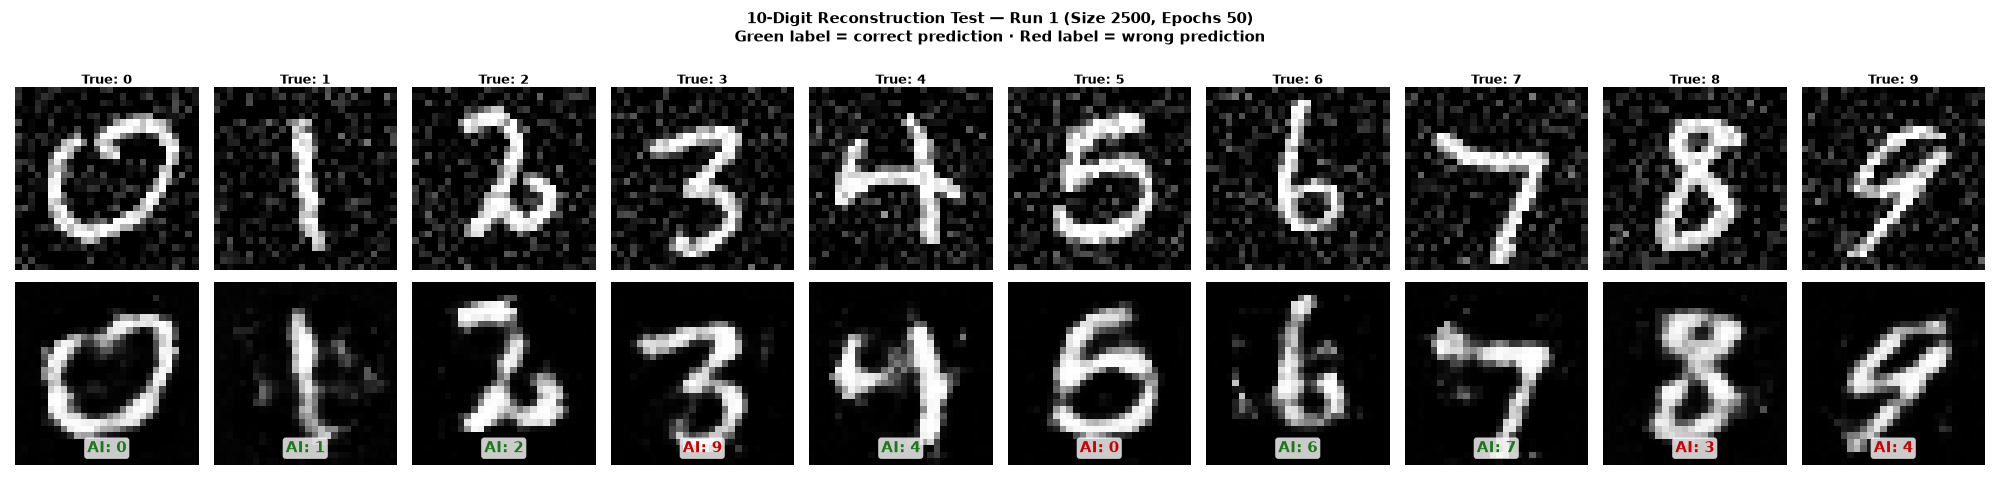

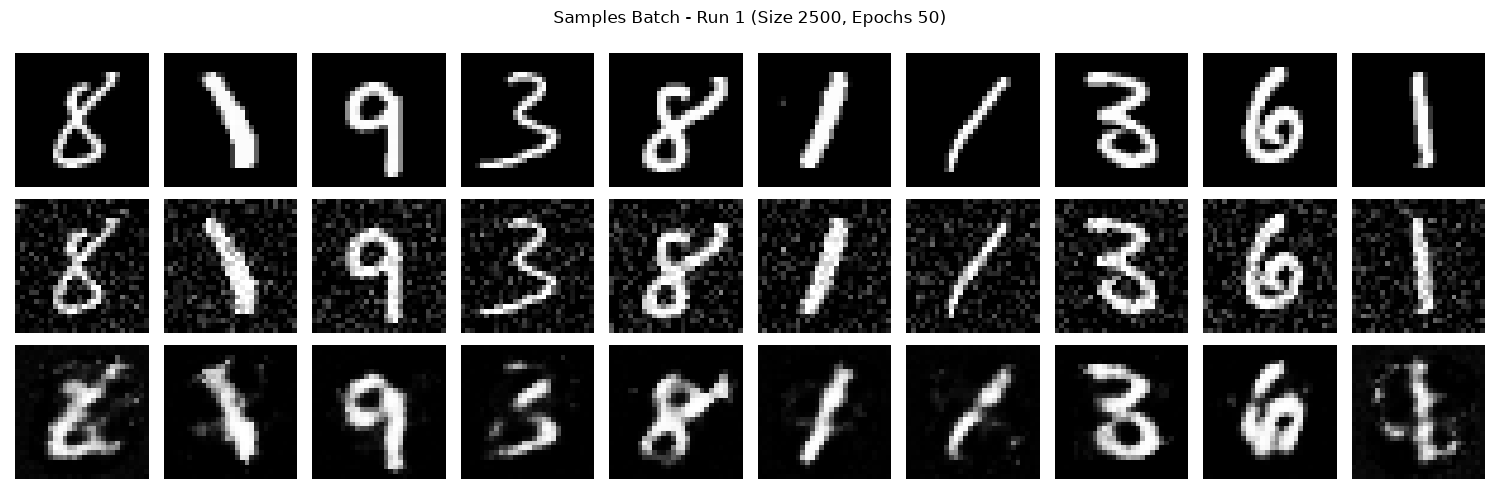

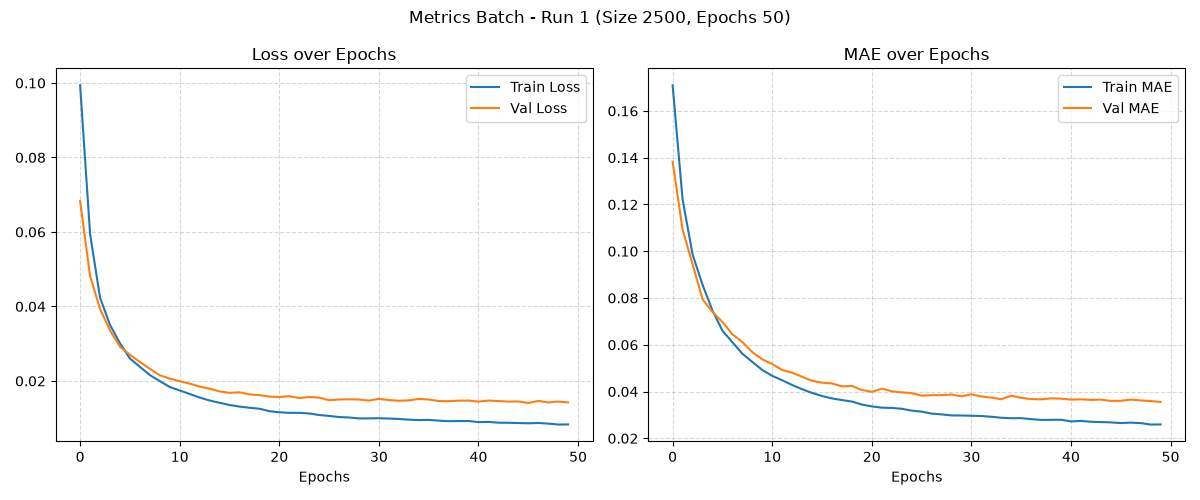

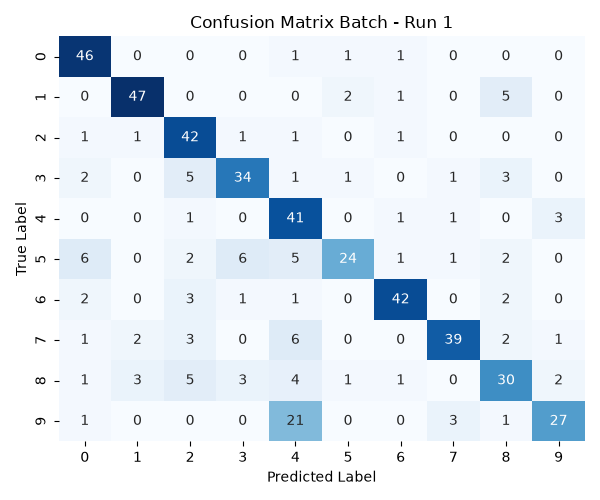


STARTING RUN 2: Size=2500, Epochs=100
Fetching MNIST dataset directly from torchvision (subset size: 2500)...
Epoch [1/100] - Train Loss: 0.1052 | Val Loss: 0.0779
Epoch [20/100] - Train Loss: 0.0126 | Val Loss: 0.0166
Epoch [40/100] - Train Loss: 0.0093 | Val Loss: 0.0145
Epoch [60/100] - Train Loss: 0.0082 | Val Loss: 0.0139
Epoch [80/100] - Train Loss: 0.0079 | Val Loss: 0.0144
Epoch [100/100] - Train Loss: 0.0076 | Val Loss: 0.0139
Saved epoch loss CSV: output/epoch_loss_s2500_e100.csv


C:\Users\Sanc\AppData\Local\Temp\ipykernel_21188\1024864177.py:110: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  val_tensor = torch.tensor(val_loader.dataset.tensors[0], dtype=torch.float32).to(DEVICE)



Displaying batch training artifacts for Run 2:


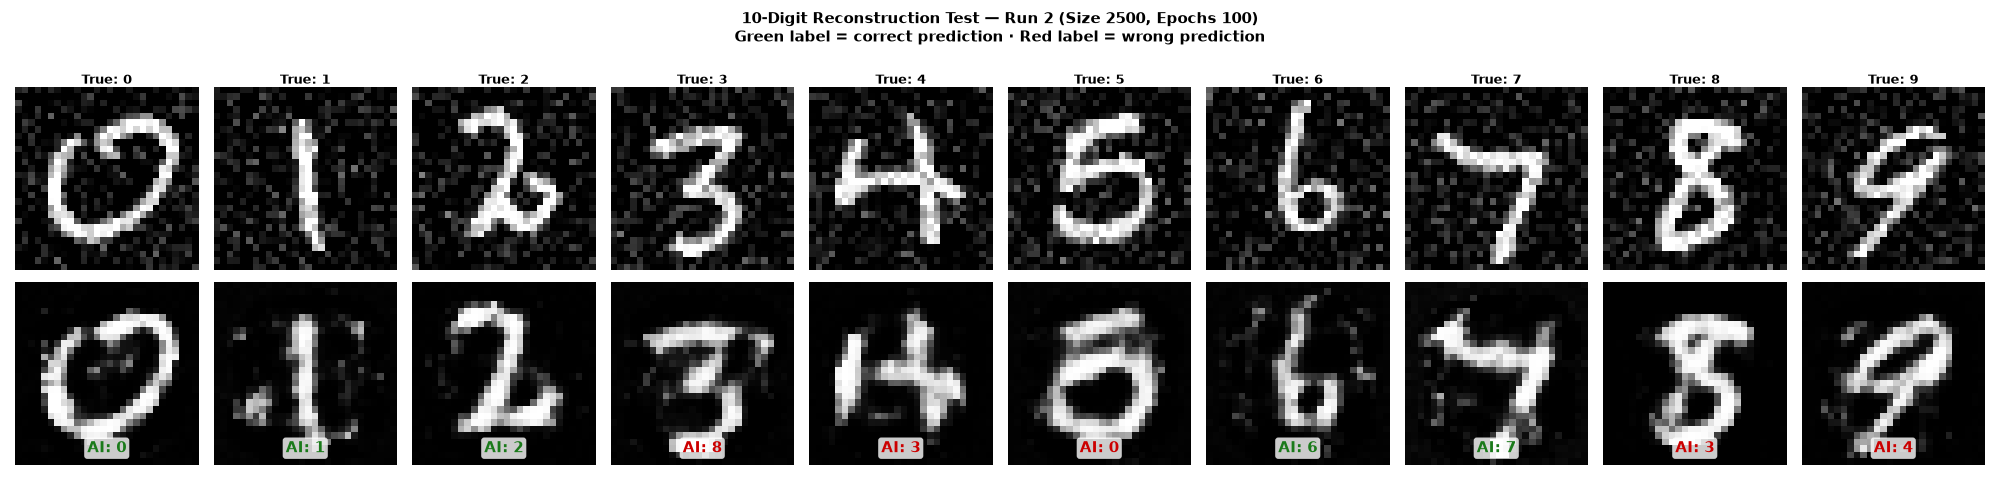

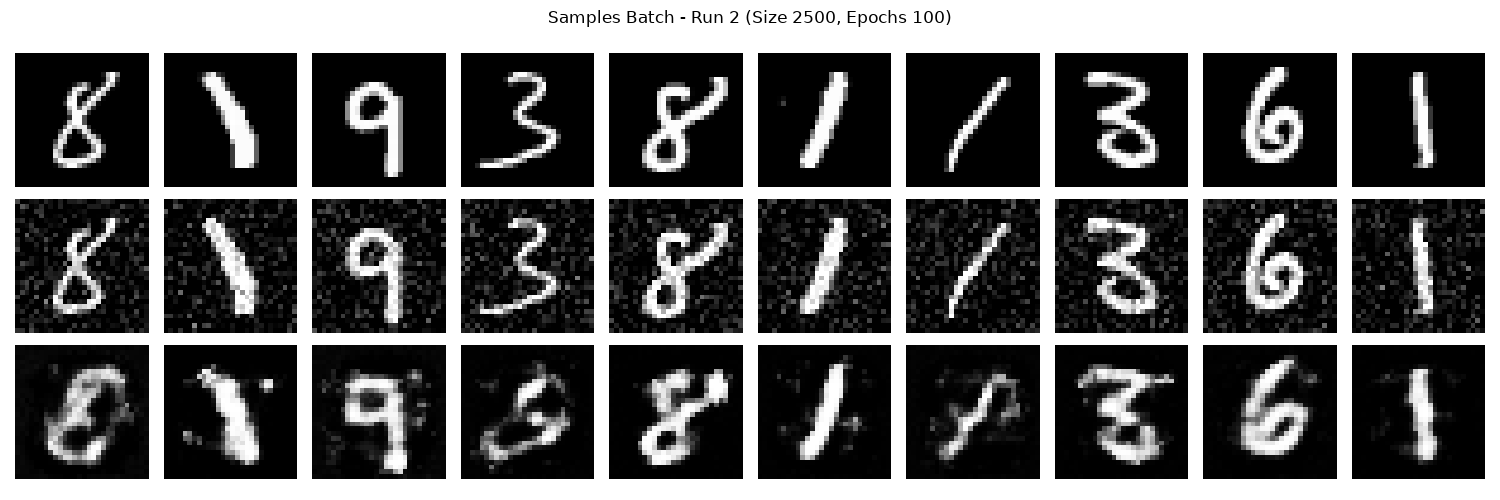

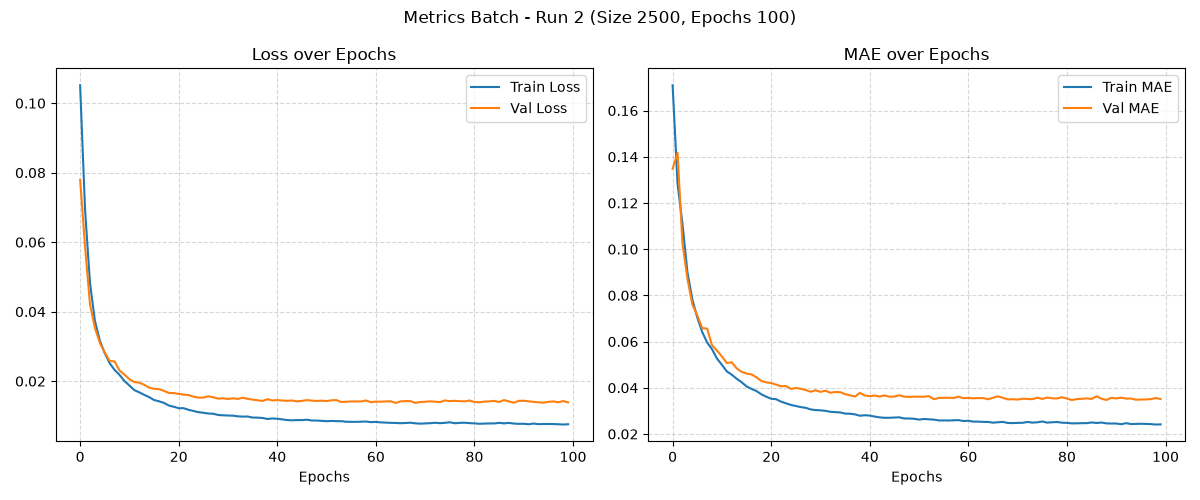

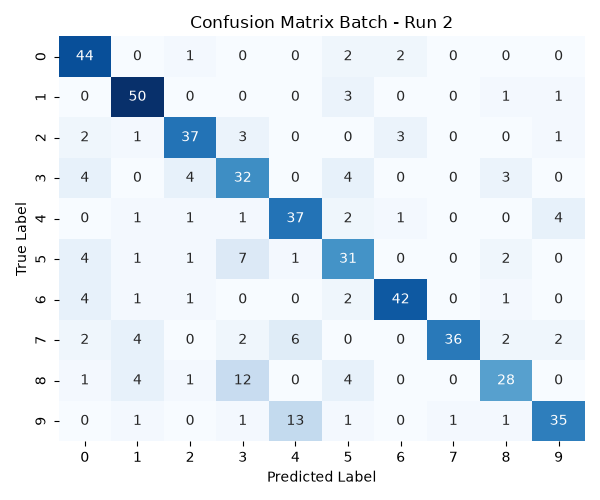


STARTING RUN 3: Size=5000, Epochs=50
Fetching MNIST dataset directly from torchvision (subset size: 5000)...
Epoch [1/50] - Train Loss: 0.1131 | Val Loss: 0.1171
Epoch [10/50] - Train Loss: 0.0170 | Val Loss: 0.0179
Epoch [20/50] - Train Loss: 0.0115 | Val Loss: 0.0134
Epoch [30/50] - Train Loss: 0.0097 | Val Loss: 0.0126
Epoch [40/50] - Train Loss: 0.0090 | Val Loss: 0.0118
Epoch [50/50] - Train Loss: 0.0086 | Val Loss: 0.0119
Saved epoch loss CSV: output/epoch_loss_s5000_e50.csv


C:\Users\Sanc\AppData\Local\Temp\ipykernel_21188\1024864177.py:110: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  val_tensor = torch.tensor(val_loader.dataset.tensors[0], dtype=torch.float32).to(DEVICE)



Displaying batch training artifacts for Run 3:


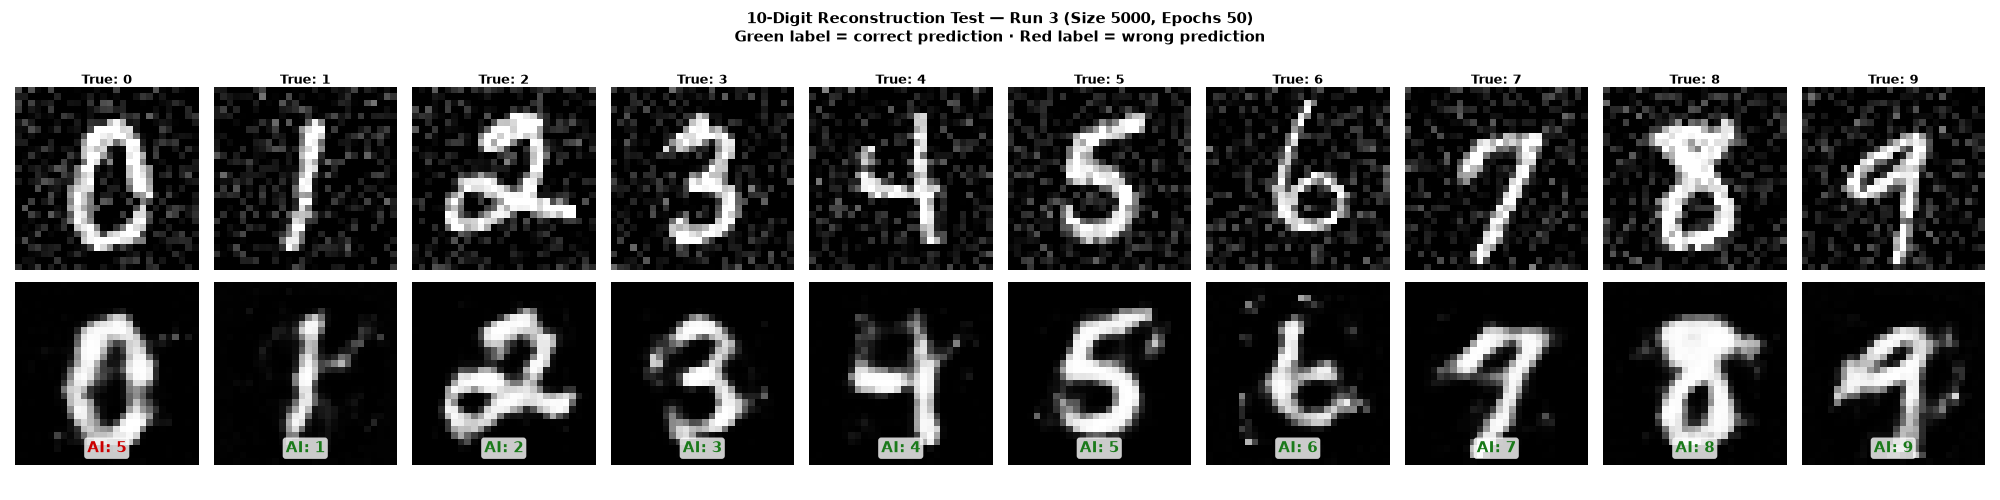

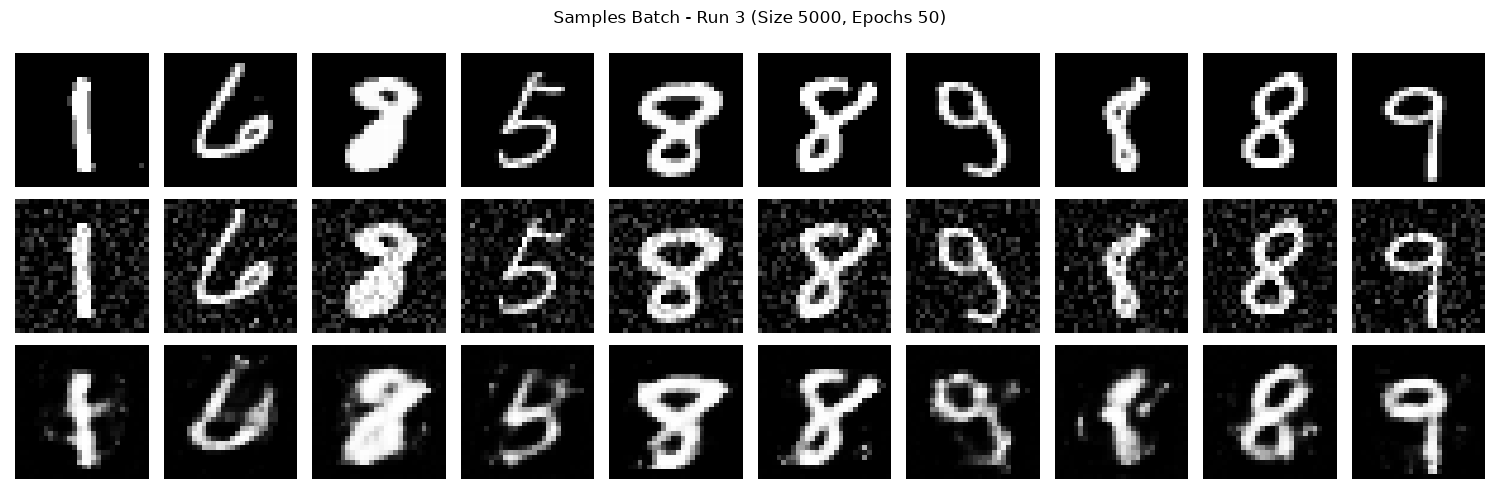

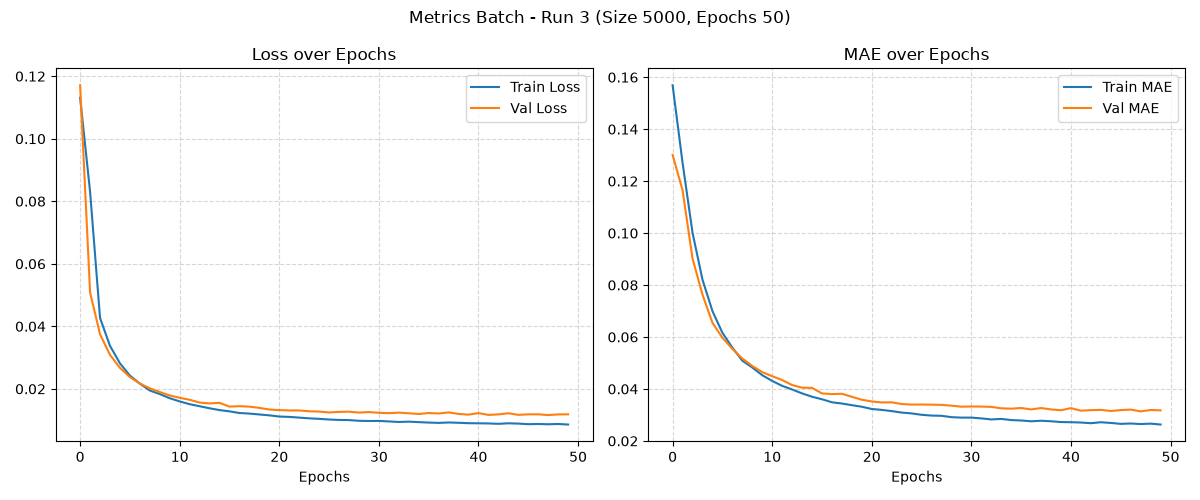

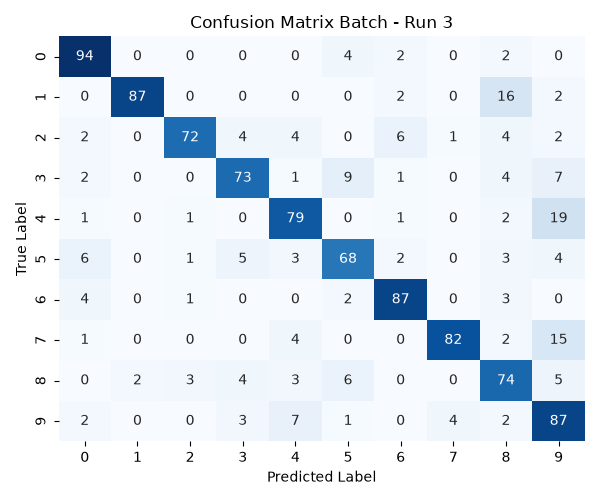


STARTING RUN 4: Size=5000, Epochs=100
Fetching MNIST dataset directly from torchvision (subset size: 5000)...
Epoch [1/100] - Train Loss: 0.0887 | Val Loss: 0.0598
Epoch [20/100] - Train Loss: 0.0106 | Val Loss: 0.0132
Epoch [40/100] - Train Loss: 0.0092 | Val Loss: 0.0126
Epoch [60/100] - Train Loss: 0.0087 | Val Loss: 0.0121
Epoch [80/100] - Train Loss: 0.0086 | Val Loss: 0.0118
Epoch [100/100] - Train Loss: 0.0083 | Val Loss: 0.0115
Saved epoch loss CSV: output/epoch_loss_s5000_e100.csv


C:\Users\Sanc\AppData\Local\Temp\ipykernel_21188\1024864177.py:110: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  val_tensor = torch.tensor(val_loader.dataset.tensors[0], dtype=torch.float32).to(DEVICE)



Displaying batch training artifacts for Run 4:


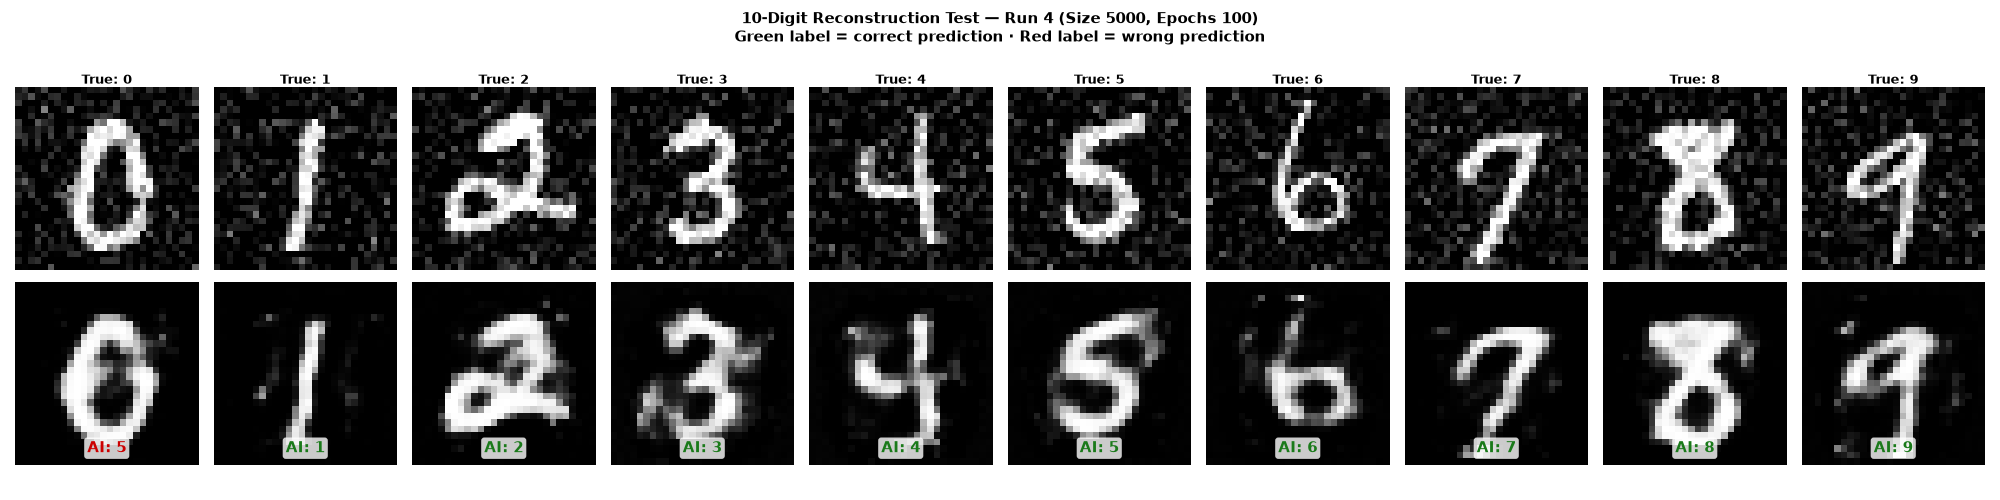

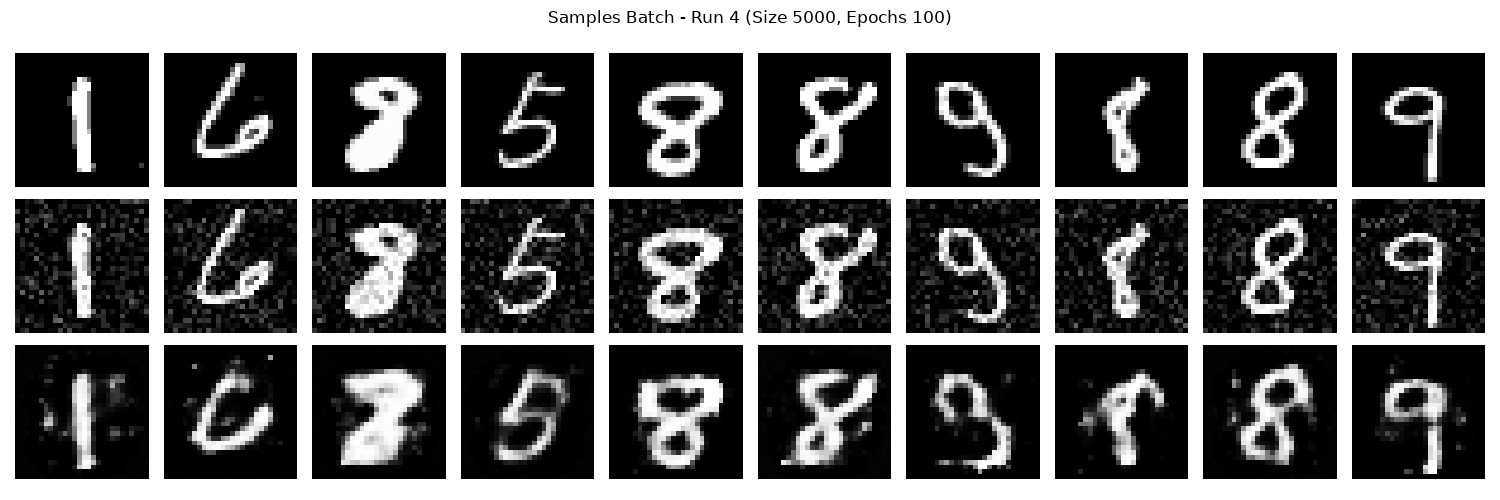

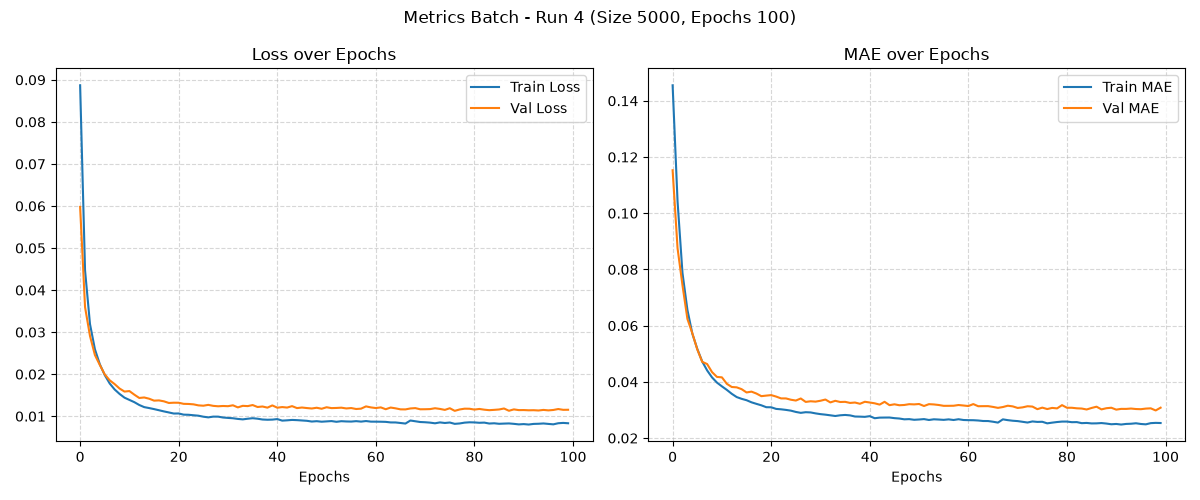

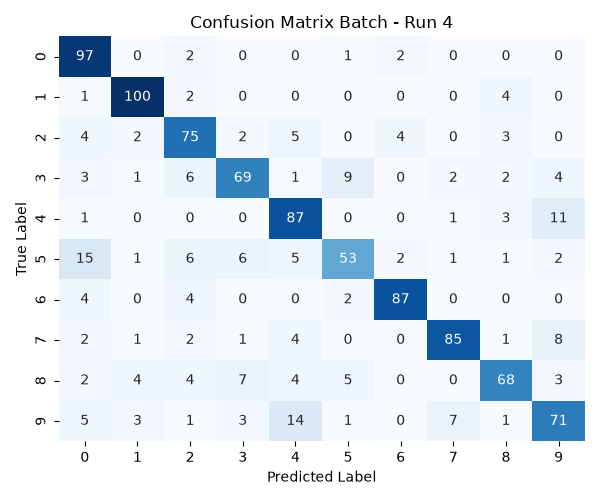


FINAL PERFORMANCE SUMMARY


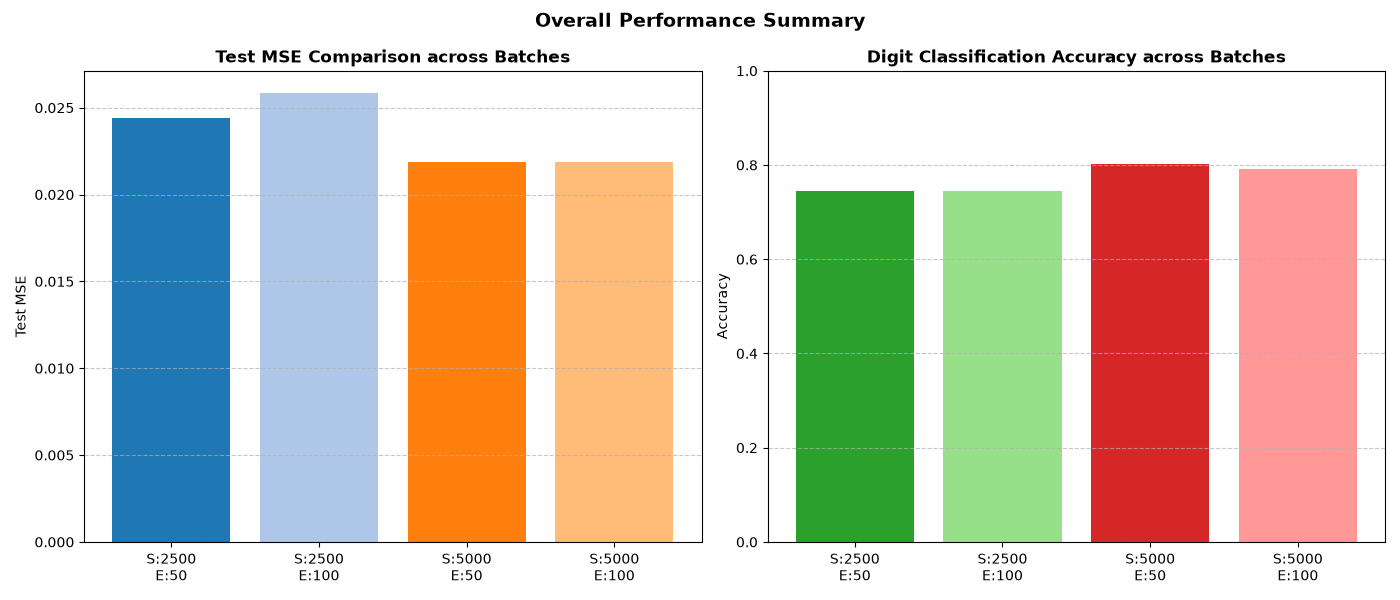


Summary Table (rounded to 4 decimal places):
 Size  Epoch  Train Loss  Val Loss  Train MSE  Val MSE  Test MSE  Train MAE  Val MAE  Digit Accuracy
 2500     50      0.0083    0.0142     0.0058   0.0120    0.0244     0.0250   0.0355           0.744
 2500    100      0.0076    0.0139     0.0051   0.0120    0.0258     0.0237   0.0352           0.744
 5000     50      0.0086    0.0119     0.0064   0.0098    0.0219     0.0262   0.0317           0.803
 5000    100      0.0083    0.0115     0.0060   0.0096    0.0219     0.0252   0.0308           0.792


In [7]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, confusion_matrix
from IPython.display import Image, display as ipy_display

# Ensure output directory exists
os.makedirs("output", exist_ok=True)

run_results = {}
csv_data = []

def get_predictions(reconstructed, X_train, y_train):
    digit_prototypes = np.array([X_train[y_train == d].mean(axis=0) for d in range(10)])
    proto_norm = digit_prototypes / (np.linalg.norm(digit_prototypes, axis=1, keepdims=True) + 1e-8)
    recon_norm = reconstructed / (np.linalg.norm(reconstructed, axis=1, keepdims=True) + 1e-8)
    cosine_sim = np.dot(recon_norm, proto_norm.T)
    return np.argmax(cosine_sim, axis=1)

for run in runs_config:
    rid = run['run_id']
    size = run['subset_size']
    epochs = run['epochs']
    lr = run['lr']

    print("\n" + "="*50)
    print(f"STARTING RUN {rid}: Size={size}, Epochs={epochs}")
    print("="*50)

    X_flat, y = get_dataset_subset(size)
    train_loader, val_loader, X_train, y_train, X_test, X_test_noisy, y_test = prepare_loaders(X_flat, y)

    model = LeakyReLUDenseAutoencoder().to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    val_losses = []
    train_maes = []
    val_maes = []

    for epoch in range(epochs):
        model.train()
        running_train_loss = 0.0
        running_train_mae = 0.0
        for data, _ in train_loader:
            data = data.to(DEVICE)
            optimizer.zero_grad()
            outputs, mu, log_var = model(data)
            recon_loss = criterion(outputs, data)
            kl_loss = -0.5 * torch.mean(1 + log_var - mu.pow(2) - log_var.exp())
            loss = recon_loss + 0.001 * kl_loss
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item() * data.size(0)
            running_train_mae += torch.mean(torch.abs(outputs - data)).item() * data.size(0)

        epoch_train_loss = running_train_loss / len(train_loader.dataset)
        epoch_train_mae = running_train_mae / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)
        train_maes.append(epoch_train_mae)

        model.eval()
        running_val_loss = 0.0
        running_val_mae = 0.0
        with torch.no_grad():
            for data, _ in val_loader:
                data = data.to(DEVICE)
                outputs, mu, log_var = model(data)
                recon_loss = criterion(outputs, data)
                kl_loss = -0.5 * torch.mean(1 + log_var - mu.pow(2) - log_var.exp())
                loss = recon_loss + 0.001 * kl_loss

                running_val_loss += loss.item() * data.size(0)
                running_val_mae += torch.mean(torch.abs(outputs - data)).item() * data.size(0)

        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        epoch_val_mae = running_val_mae / len(val_loader.dataset)
        val_losses.append(epoch_val_loss)
        val_maes.append(epoch_val_mae)

        if (epoch + 1) % (epochs // 5) == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")

    # Export per-run epoch loss CSV
    epoch_loss_df = pd.DataFrame({
        "epoch": range(1, epochs + 1),
        "training_loss": train_losses,
        "validation_loss": val_losses
    })
    epoch_loss_path = f"output/epoch_loss_s{size}_e{epochs}.csv"
    epoch_loss_df.to_csv(epoch_loss_path, index=False)
    print(f"Saved epoch loss CSV: {epoch_loss_path}")

    # Evaluate on noisy test set
    model.eval()
    with torch.no_grad():
        # Train reconstruction
        train_tensor = torch.tensor(X_train, dtype=torch.float32).to(DEVICE)
        train_recon, _, _ = model(train_tensor)
        train_recon = train_recon.cpu().numpy()

        # Val reconstruction
        val_tensor = torch.tensor(val_loader.dataset.tensors[0], dtype=torch.float32).to(DEVICE)
        val_recon, _, _ = model(val_tensor)
        val_recon = val_recon.cpu().numpy()

        # Test reconstruction
        test_noisy_tensor = torch.tensor(X_test_noisy, dtype=torch.float32).to(DEVICE)
        reconstructed, _, _ = model(test_noisy_tensor)
        reconstructed = reconstructed.cpu().numpy()

    # Calculate Metrics
    train_mse = mean_squared_error(X_train, train_recon)
    val_mse = mean_squared_error(val_loader.dataset.tensors[0].numpy(), val_recon)
    test_mse = mean_squared_error(X_test, reconstructed)
    train_mae = mean_absolute_error(X_train, train_recon)
    val_mae = mean_absolute_error(val_loader.dataset.tensors[0].numpy(), val_recon)

    preds = get_predictions(reconstructed, X_train, y_train)
    digit_acc = np.mean(preds == y_test)

    # Save metrics data for CSV
    csv_data.append({
        "Size": size,
        "Epoch": epochs,
        "Train Loss": train_losses[-1],
        "Val Loss": val_losses[-1],
        "Train MSE": train_mse,
        "Val MSE": val_mse,
        "Test MSE": test_mse,
        "Train MAE": train_mae,
        "Val MAE": val_mae,
        "Digit Accuracy": digit_acc
    })

    # Cache results for global visualization if needed
    run_results[rid] = {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "X_train": X_train,
        "y_train": y_train,
        "X_test": X_test,
        "X_test_noisy": X_test_noisy,
        "y_test": y_test,
        "reconstructed": reconstructed,
        "digit_accuracy": digit_acc,
        "test_mse": test_mse
    }

    # --- GENERATING INDIVIDUAL VISUALIZATIONS FOR THE CURRENT BATCH ---

    # 1. Samples Batch Plot
    fig_samples, axes = plt.subplots(3, 10, figsize=(15, 5))
    sample_indices = np.random.RandomState(SEED).choice(len(X_test), 10, replace=False)
    for i, idx in enumerate(sample_indices):
        axes[0, i].imshow(X_test[idx].reshape(28, 28), cmap='gray')
        axes[0, i].axis('off')
        axes[1, i].imshow(X_test_noisy[idx].reshape(28, 28), cmap='gray')
        axes[1, i].axis('off')
        axes[2, i].imshow(reconstructed[idx].reshape(28, 28), cmap='gray')
        axes[2, i].axis('off')
    axes[0, 0].set_ylabel("Original", rotation=0, labelpad=40, fontsize=12, fontweight='bold')
    axes[1, 0].set_ylabel("Noisy", rotation=0, labelpad=40, fontsize=12, fontweight='bold')
    axes[2, 0].set_ylabel("Reconstructed", rotation=0, labelpad=40, fontsize=12, fontweight='bold')
    fig_samples.suptitle(f"Samples Batch - Run {rid} (Size {size}, Epochs {epochs})")
    plt.tight_layout()
    samples_path = f"output/samples_batch_{rid}.png"
    fig_samples.savefig(samples_path)
    plt.close(fig_samples)

    # 2. Metrics Batch Plot
    fig_metrics, (ax_l, ax_m) = plt.subplots(1, 2, figsize=(12, 5))
    ax_l.plot(train_losses, label="Train Loss")
    ax_l.plot(val_losses, label="Val Loss")
    ax_l.set_title("Loss over Epochs")
    ax_l.set_xlabel("Epochs")
    ax_l.grid(True, linestyle="--", alpha=0.5)
    ax_l.legend()

    ax_m.plot(train_maes, label="Train MAE")
    ax_m.plot(val_maes, label="Val MAE")
    ax_m.set_title("MAE over Epochs")
    ax_m.set_xlabel("Epochs")
    ax_m.grid(True, linestyle="--", alpha=0.5)
    ax_m.legend()
    fig_metrics.suptitle(f"Metrics Batch - Run {rid} (Size {size}, Epochs {epochs})")
    plt.tight_layout()
    metrics_path = f"output/metrics_batch_{rid}.png"
    fig_metrics.savefig(metrics_path)
    plt.close(fig_metrics)

    # 3. Confusion Matrix Plot
    fig_cm, ax_cm = plt.subplots(figsize=(6, 5))
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax_cm)
    ax_cm.set_title(f"Confusion Matrix Batch - Run {rid}")
    ax_cm.set_xlabel("Predicted Label")
    ax_cm.set_ylabel("True Label")
    plt.tight_layout()
    cm_path = f"output/confusion_matrix_batch_{rid}.png"
    fig_cm.savefig(cm_path)
    plt.close(fig_cm)


    # 4. Result 10 Digits Batch Plot
    # Pick one clean example of each digit 0-9 from the test set
    digit10_path = f"output/result_10digits_batch_{rid}.png"
    fig_d10, axes_d10 = plt.subplots(2, 10, figsize=(20, 5))
    for d in range(10):
        # Find first occurrence of this digit in the test set
        digit_indices = np.where(y_test == d)[0]
        if len(digit_indices) == 0:
            for ax in axes_d10[:, d]:
                ax.axis('off')
            continue
        idx_d = digit_indices[0]

        # Reconstruct the noisy version of this digit
        single_noisy = torch.tensor(X_test_noisy[idx_d:idx_d+1], dtype=torch.float32).to(DEVICE)
        with torch.no_grad():
            recon_single, _, _ = model(single_noisy)
        recon_img = recon_single.cpu().numpy()[0]

        # Get the model's predicted label for this reconstruction
        pred_label = get_predictions(recon_img[np.newaxis, :], X_train, y_train)[0]
        correct = (pred_label == d)
        label_color = "#1a7a1a" if correct else "#cc0000"

        # Top row: noisy input
        axes_d10[0, d].imshow(X_test_noisy[idx_d].reshape(28, 28), cmap='gray')
        axes_d10[0, d].axis('off')
        axes_d10[0, d].set_title(f"True: {d}", fontsize=9, color='black',
                                  fontweight='bold', pad=2)

        # Bottom row: reconstruction with predicted label overlay
        axes_d10[1, d].imshow(recon_img.reshape(28, 28), cmap='gray')
        axes_d10[1, d].axis('off')
        # Overlay predicted label text centered on the image
        axes_d10[1, d].text(
            0.5, 0.05, f"AI: {pred_label}",
            transform=axes_d10[1, d].transAxes,
            fontsize=11, fontweight='bold', color=label_color,
            ha='center', va='bottom',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='none')
        )

    axes_d10[0, 0].set_ylabel("Noisy Input", rotation=0, labelpad=55,
                               fontsize=10, fontweight='bold', color='black')
    axes_d10[1, 0].set_ylabel("Reconstructed", rotation=0, labelpad=55,
                               fontsize=10, fontweight='bold', color='black')
    fig_d10.suptitle(
        f"10-Digit Reconstruction Test — Run {rid} (Size {size}, Epochs {epochs})\n"
        f"Green label = correct prediction · Red label = wrong prediction",
        fontsize=11, fontweight='bold', color='black'
    )
    fig_d10.patch.set_facecolor('white')
    for ax_row in axes_d10:
        for ax in ax_row:
            ax.set_facecolor('white')
    plt.tight_layout()
    fig_d10.savefig(digit10_path, facecolor='white')
    plt.close(fig_d10)

    # Display the three generated batch files immediately
    print(f"\nDisplaying batch training artifacts for Run {rid}:")
    ipy_display(Image(filename=digit10_path))
    ipy_display(Image(filename=samples_path))
    ipy_display(Image(filename=metrics_path))
    ipy_display(Image(filename=cm_path))

# Create Pandas DataFrames for results
df_full = pd.DataFrame(csv_data)
df_rounded = df_full.copy()
# Round numeric columns to 4 decimal places
numeric_cols = df_rounded.select_dtypes(include=[np.number]).columns.drop(["Size", "Epoch"], errors="ignore")
df_rounded[numeric_cols] = df_rounded[numeric_cols].round(4)

# Export CSVs to output/
df_full.to_csv("output/results_full.csv", index=False)
df_rounded.to_csv("output/results.csv", index=False)

# --- GENERATE SUMMARY PLOT ---
fig_summary, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
batch_names = [f"S:{r['Size']}\nE:{r['Epoch']}" for r in csv_data]
test_mses = [r['Test MSE'] for r in csv_data]
accuracies = [r['Digit Accuracy'] for r in csv_data]

# Test MSE Bar Chart
ax1.bar(batch_names, test_mses, color=['#1f77b4', '#aec7e8', '#ff7f0e', '#ffbb78'])
ax1.set_title("Test MSE Comparison across Batches", fontweight='bold')
ax1.set_ylabel("Test MSE")
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Accuracy Bar Chart
ax2.bar(batch_names, accuracies, color=['#2ca02c', '#98df8a', '#d62728', '#ff9896'])
ax2.set_title("Digit Classification Accuracy across Batches", fontweight='bold')
ax2.set_ylabel("Accuracy")
ax2.set_ylim(0, 1.0)
ax2.grid(axis='y', linestyle='--', alpha=0.7)

fig_summary.suptitle("Overall Performance Summary", fontsize=14, fontweight='bold')
plt.tight_layout()
fig_summary.savefig("output/summary_plot.png")
plt.close(fig_summary)

# Display the final summary plot and print the rounded dataframe table
print("\n" + "="*50)
print("FINAL PERFORMANCE SUMMARY")
print("="*50)
ipy_display(Image(filename="output/summary_plot.png"))

# Print the summary table as the final block evaluation output
print("\nSummary Table (rounded to 4 decimal places):")
print(df_rounded.to_string(index=False))

## 7. Deliverable Visualizations

We plot learning behaviors, denoising comparisons, and confusion representations of the structural output accuracy.

OVERALL PERFORMANCE SUMMARY PLOT


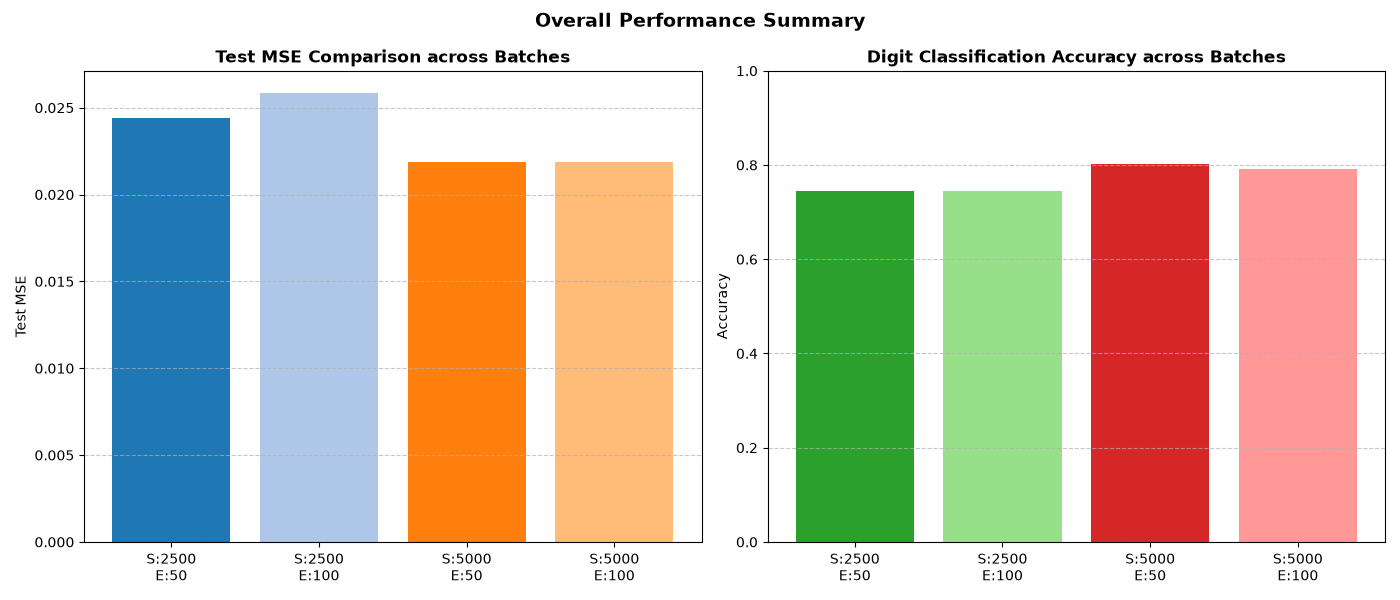


Summary Table (rounded to 4 decimal places):


,Size,Epoch,Train Loss,Val Loss,Train MSE,Val MSE,Test MSE,Train MAE,Val MAE,Digit Accuracy
0,2500,50,0.0083,0.0142,0.0058,0.0120,0.0244,0.0250,0.0355,0.744
1,2500,100,0.0076,0.0139,0.0051,0.0120,0.0258,0.0237,0.0352,0.744
2,5000,50,0.0086,0.0119,0.0064,0.0098,0.0219,0.0262,0.0317,0.803
3,5000,100,0.0083,0.0115,0.0060,0.0096,0.0219,0.0252,0.0308,0.792


In [8]:
import pandas as pd
from IPython.display import Image, display as ipy_display

# Display the final summary plot
print("=" * 55)
print("OVERALL PERFORMANCE SUMMARY PLOT")
print("=" * 55)
ipy_display(Image(filename="output/summary_plot.png"))

# Load and display the rounded results table
print("\nSummary Table (rounded to 4 decimal places):")
df_rounded = pd.read_csv("output/results.csv")
ipy_display(df_rounded)
